## Packages

In [1]:
import numpy as np
import pandas as pd
import scipy
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import statsmodels.graphics.tsaplots as sgt
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima.arima import auto_arima
from arch import arch_model
import yfinance
import warnings
warnings.filterwarnings("ignore")
sns.set()

## Loading the data

In [2]:
raw_data = yfinance.download (tickers = "^GSPC ^FTSE ^N225 ^GDAXI", start = "1994-01-07", 
                              end = "2019-09-01", interval = "1d", group_by = 'ticker', auto_adjust = True, threads = True)

[*********************100%***********************]  4 of 4 completed


In [3]:
df_comp = raw_data.copy()

In [4]:
df_comp['spx'] = df_comp['^GSPC'].Close[:]
df_comp['dax'] = df_comp['^GDAXI'].Close[:]
df_comp['ftse'] = df_comp['^FTSE'].Close[:]
df_comp['nikkei'] = df_comp['^N225'].Close[:]

In [5]:
df_comp = df_comp.iloc[1:]
del df_comp['^N225']
del df_comp['^GSPC']
del df_comp['^GDAXI']
del df_comp['^FTSE']
df_comp=df_comp.asfreq('b')
df_comp=df_comp.fillna(method='ffill')

## Creating Returns

In [6]:
df_comp['ret_spx'] = df_comp.spx.pct_change(1).mul(100)
df_comp['ret_ftse'] = df_comp.ftse.pct_change(1).mul(100)
df_comp['ret_dax'] = df_comp.dax.pct_change(1).mul(100)
df_comp['ret_nikkei'] = df_comp.nikkei.pct_change(1).mul(100)

In [7]:
df_comp['norm_ret_spx'] = df_comp.ret_spx.div(df_comp.ret_spx[1])*100
df_comp['norm_ret_ftse'] = df_comp.ret_ftse.div(df_comp.ret_ftse[1])*100
df_comp['norm_ret_dax'] = df_comp.ret_dax.div(df_comp.ret_dax[1])*100
df_comp['norm_ret_nikkei'] = df_comp.ret_nikkei.div(df_comp.ret_nikkei[1])*100

## Splitting the Data

In [8]:
size = int(len(df_comp)*0.8)
df, df_test = df_comp.iloc[:size], df_comp.iloc[size:]

## Fitting a Model

In [9]:
model_ar = ARIMA(df.ftse, order = (1,0,0))
results_ar = model_ar.fit()

## Simple Forecasting

In [10]:
df.tail()

Ticker,spx,dax,ftse,nikkei,ret_spx,ret_ftse,ret_dax,ret_nikkei,norm_ret_spx,norm_ret_ftse,norm_ret_dax,norm_ret_nikkei
Price,,,,,,,,,,,,
Date,,,,,,,,,,,,
2014-07-09,1972.829956,9808.200195,6718.000000,15302.650391,0.464427,-0.304222,0.363568,-0.076789,-193.623849,39.056133,260.939581,-33.873062
2014-07-10,1964.680054,9659.129883,6672.399902,15216.469727,-0.413107,-0.678775,-1.519854,-0.563175,172.228229,87.141370,-1090.828512,-248.427258
2014-07-11,1967.569946,9666.339844,6690.200195,15164.040039,0.147092,0.266775,0.074644,-0.344559,-61.324138,-34.248669,53.573442,-151.991545
2014-07-14,1977.099976,9783.009766,6746.100098,15296.820312,0.484355,0.835549,1.206971,0.875626,-201.932230,-107.268090,866.266436,386.255523
2014-07-15,1973.280029,9719.410156,6710.500000,15395.160156,-0.193210,-0.527714,-0.650103,0.642878,80.550866,67.748084,-466.591262,283.585757


In [11]:
# create variables that will help us change the periods easily instead of typing them up every time
# make sure the start and end dates are business days, otherwise the code will result in an error
start_date = "2014-07-16"
end_date = "2015-01-01"

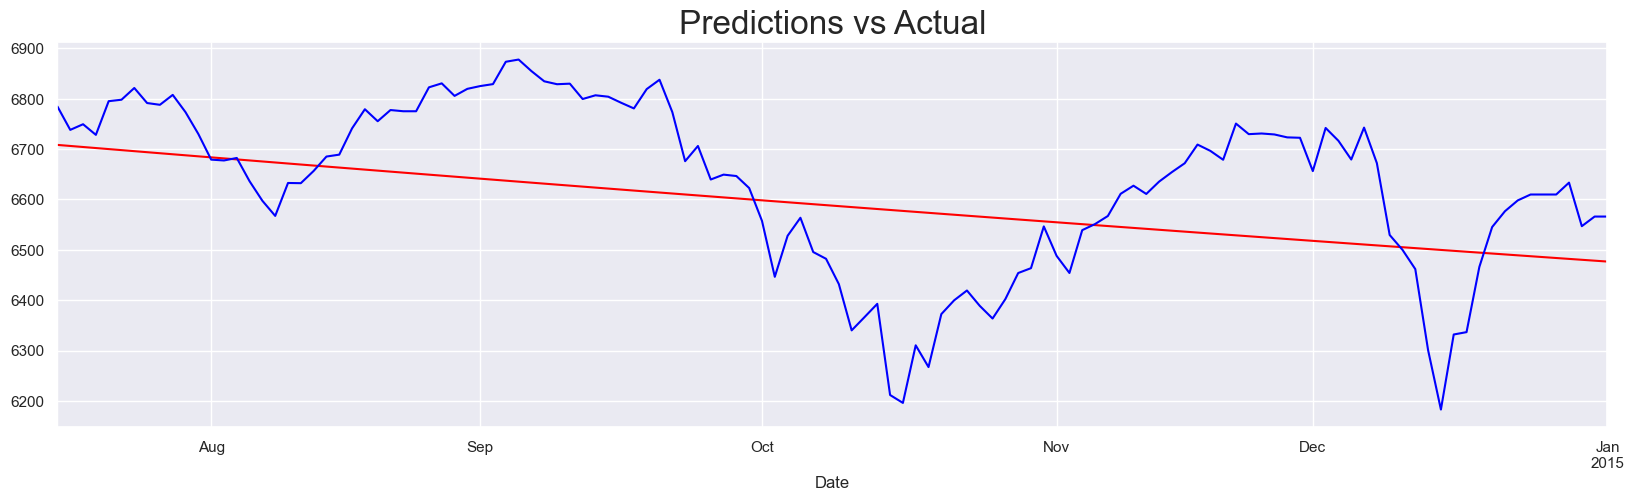

In [12]:
df_pred = results_ar.predict(start = start_date, end = end_date)

df_pred[start_date:end_date].plot(figsize = (20,5), color = "red")
df_test.ftse[start_date:end_date].plot(color = "blue")
plt.title("Predictions vs Actual", size = 24)
plt.show()

In [13]:
end_date = "2019-10-23"
df_pred = results_ar.predict(start = start_date, end = end_date)

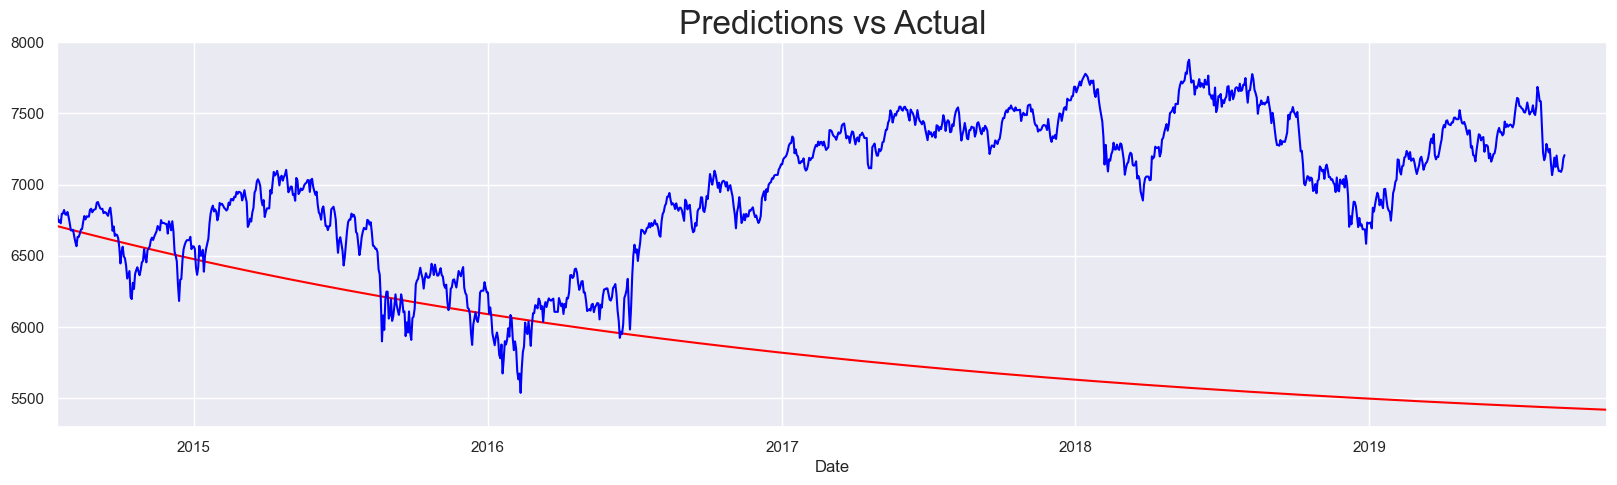

In [14]:
df_pred[start_date:end_date].plot(figsize = (20,5), color = "red")
df_test.ftse[start_date:end_date].plot(color = "blue")
plt.title("Predictions vs Actual", size = 24)
plt.show()

Whit this we can see that the AR models are so bad at estimating non-stationary data

### Using Returns Instead

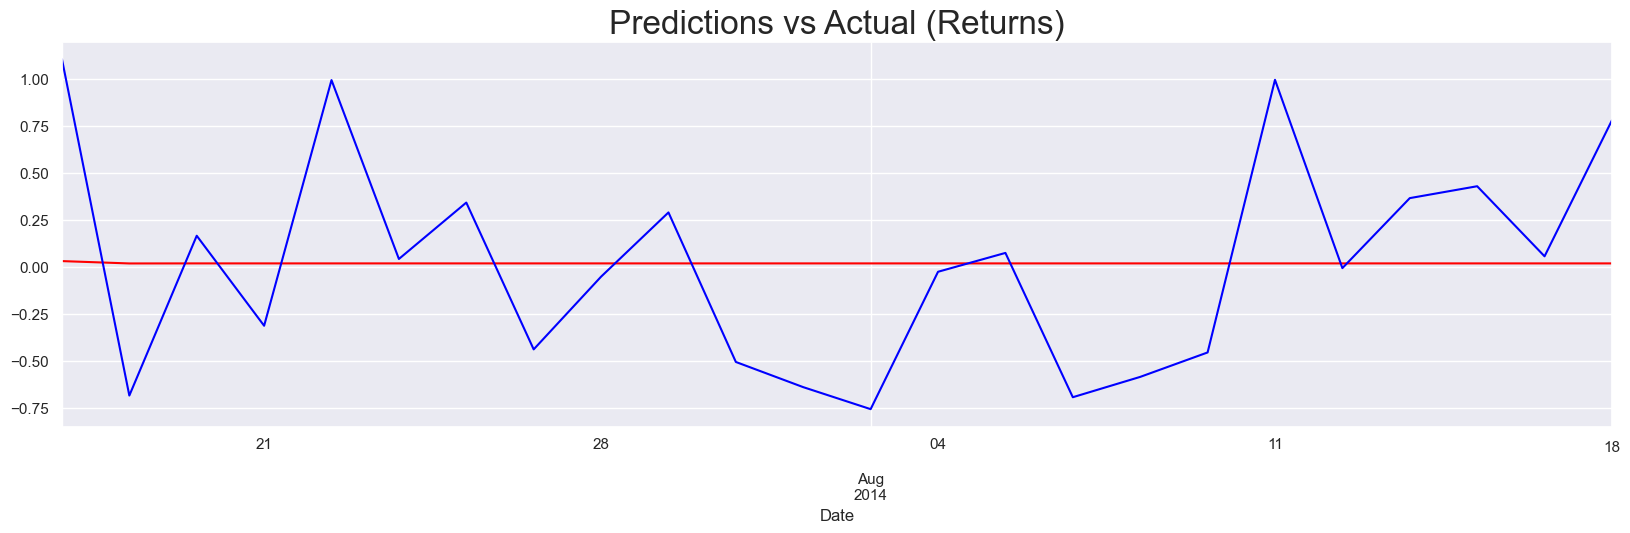

In [15]:
end_date = "2014-08-18"

model_ret_ar = ARIMA(df.ret_ftse[1:], order = (1,0,0))
results_ret_ar = model_ret_ar.fit()

df_pred_ar = results_ret_ar.predict(start = start_date, end = end_date) 

df_pred_ar[start_date:end_date].plot(figsize = (20,5), color = "red")
df_test.ret_ftse[start_date:end_date].plot(color = "blue")
plt.title("Predictions vs Actual (Returns)", size = 24)
plt.show()

In [16]:
results_ret_ar.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:               ret_ftse   No. Observations:                 5351
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -8343.712
Date:                Sun, 01 Feb 2026   AIC                          16693.424
Time:                        21:47:48   BIC                          16713.179
Sample:                    01-11-1994   HQIC                         16700.324
                         - 07-15-2014                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0191      0.016      1.226      0.220      -0.011       0.050
ar.L1         -0.0224      0.008     -2.740      0.006      -0.038      -0.006
sigma2         1.3240      0.013    104.612      0.000       1.299       1.349
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):              8959.57
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               1.91   Skew:                            -0.03
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.34
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

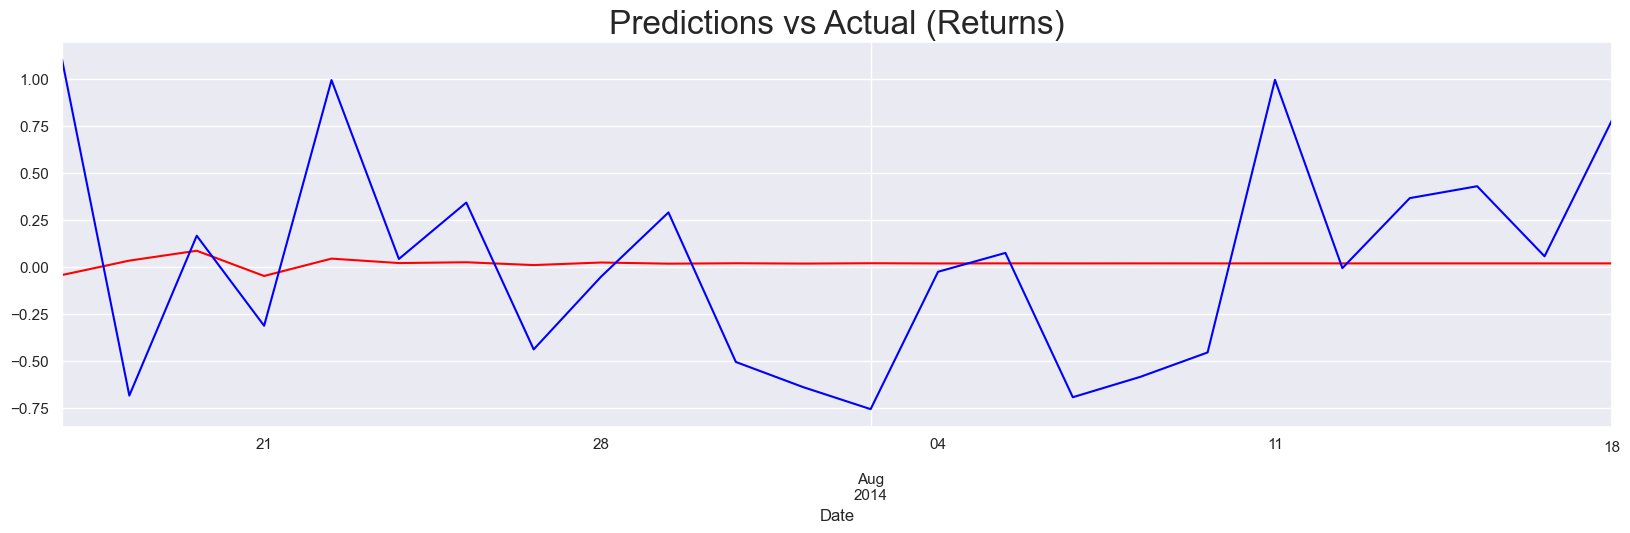

In [17]:
end_date = "2014-08-18"

model_ret_ar = ARIMA(df.ret_ftse[1:], order = (5,0,0))
results_ret_ar = model_ret_ar.fit()

df_pred_ar = results_ret_ar.predict(start = start_date, end = end_date) 

df_pred_ar[start_date:end_date].plot(figsize = (20,5), color = "red")
df_test.ret_ftse[start_date:end_date].plot(color = "blue")
plt.title("Predictions vs Actual (Returns)", size = 24)
plt.show()

In [18]:
results_ret_ar.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:               ret_ftse   No. Observations:                 5351
Model:                 ARIMA(5, 0, 0)   Log Likelihood               -8306.931
Date:                Sun, 01 Feb 2026   AIC                          16627.862
Time:                        21:47:49   BIC                          16673.958
Sample:                    01-11-1994   HQIC                         16643.963
                         - 07-15-2014                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0192      0.014      1.356      0.175      -0.009       0.047
ar.L1         -0.0214      0.009     -2.459      0.014      -0.038      -0.004
ar.L2         -0.0524      0.008     -6.858      0.000      -0.067      -0.037
ar.L3         -0.0804      0.008    -10.492      0.000      -0.095      -0.065
ar.L4          0.0423      0.008      5.335      0.000       0.027       0.058
ar.L5         -0.0572      0.008     -7.477      0.000      -0.072      -0.042
sigma2         1.3059      0.014     96.686      0.000       1.279       1.332
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):              7325.62
Prob(Q):                              0.86   Prob(JB):                         0.00
Heteroskedasticity (H):               1.89   Skew:                            -0.17
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.72
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### MA

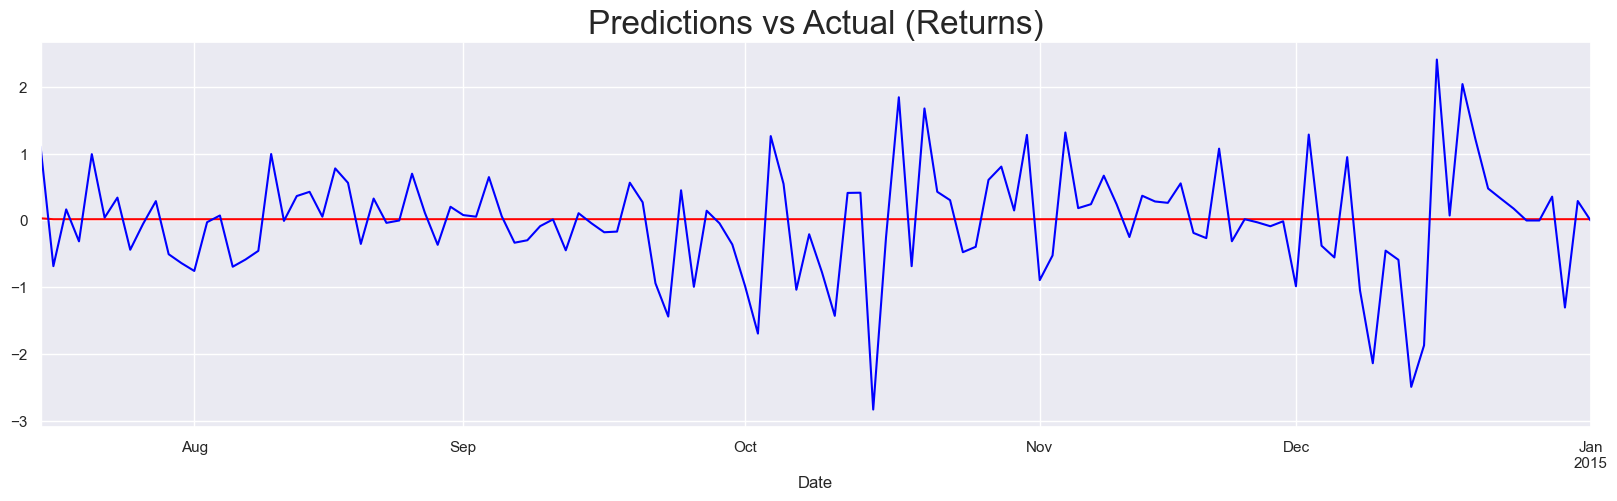

In [19]:
end_date = "2015-01-01"

model_ret_ma = ARIMA(df.ret_ftse[1:], order=(0,0,1))
results_ret_ma = model_ret_ma.fit()

df_pred_ma = results_ret_ma.predict(start = start_date, end = end_date) 

df_pred_ma[start_date:end_date].plot(figsize = (20,5), color = "red")   
df_test.ret_ftse[start_date:end_date].plot(color = "blue")
plt.title("Predictions vs Actual (Returns)", size = 24)
plt.show()

In [20]:
df_pred_ma.head()

2014-07-16    0.032249
2014-07-17    0.019113
2014-07-18    0.019113
2014-07-21    0.019113
2014-07-22    0.019113
Freq: B, Name: predicted_mean, dtype: float64

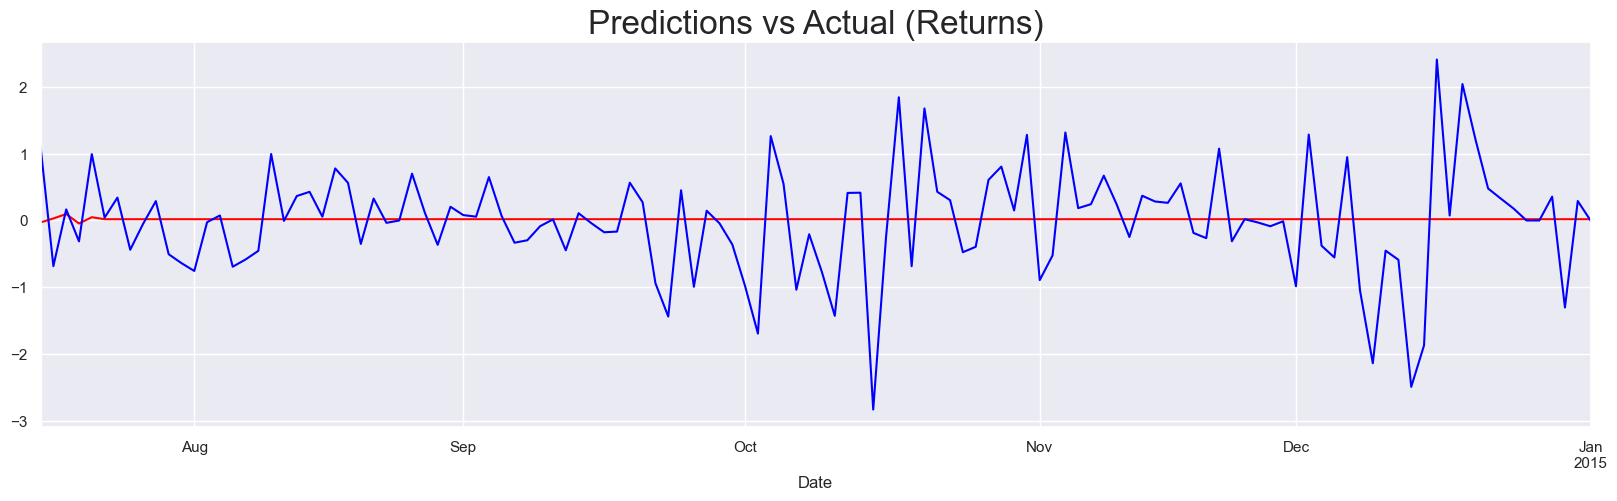

In [21]:
end_date = "2015-01-01"

model_ret_ma = ARIMA(df.ret_ftse[1:], order=(0,0,5))
results_ret_ma = model_ret_ma.fit()

df_pred_ma = results_ret_ma.predict(start = start_date, end = end_date) 

df_pred_ma[start_date:end_date].plot(figsize = (20,5), color = "red")   
df_test.ret_ftse[start_date:end_date].plot(color = "blue")
plt.title("Predictions vs Actual (Returns)", size = 24)
plt.show()

In [22]:
df_pred_ma.head()

2014-07-16   -0.029372
2014-07-17    0.030304
2014-07-18    0.096968
2014-07-21   -0.045108
2014-07-22    0.049166
Freq: B, Name: predicted_mean, dtype: float64

Whit this we can see that the forecasting powers of the simple AR and MA models are low

### ARMA

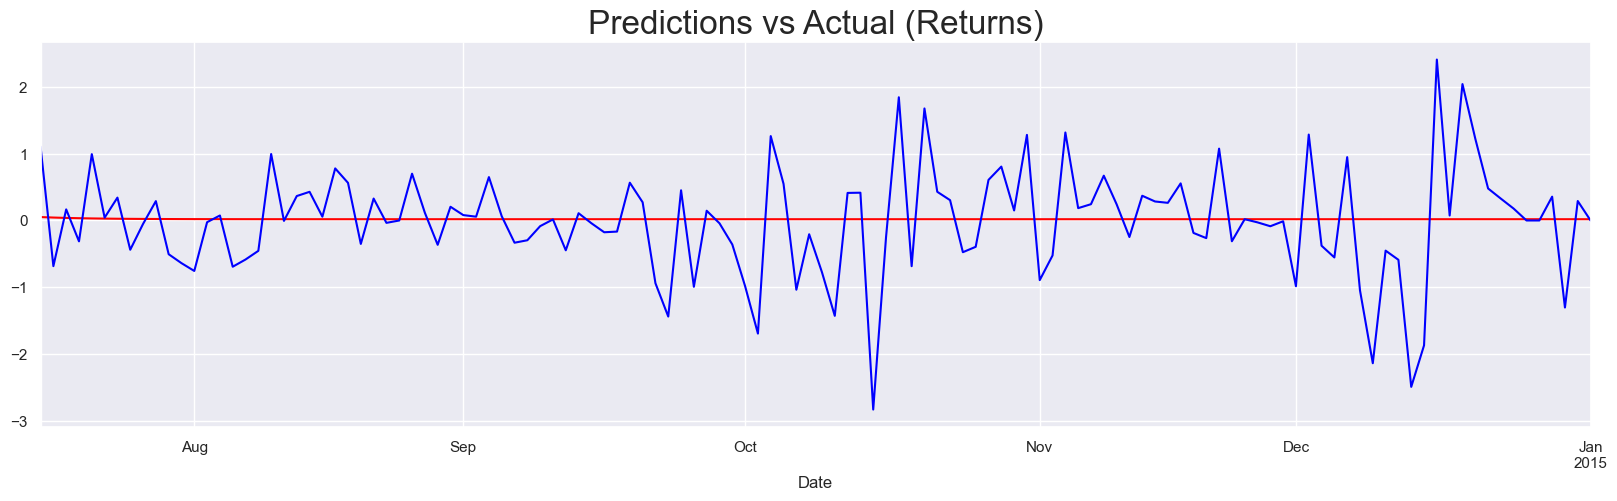

In [23]:
model_ret_arma = ARIMA(df.ret_ftse[1:], order=(1,0,1))
results_ret_arma = model_ret_arma.fit()

df_pred_arma = results_ret_arma.predict(start = start_date, end = end_date)

df_pred_arma[start_date:end_date].plot(figsize = (20,5), color = "red")   
df_test.ret_ftse[start_date:end_date].plot(color = "blue")
plt.title("Predictions vs Actual (Returns)", size = 24)
plt.show()

In [24]:
df_pred_arma.head()

2014-07-16    0.051308
2014-07-17    0.044092
2014-07-18    0.038497
2014-07-21    0.034157
2014-07-22    0.030791
Freq: B, Name: predicted_mean, dtype: float64

In [25]:
df_pred_arma.tail()

2014-12-26    0.019164
2014-12-29    0.019164
2014-12-30    0.019164
2014-12-31    0.019164
2015-01-01    0.019164
Freq: B, Name: predicted_mean, dtype: float64

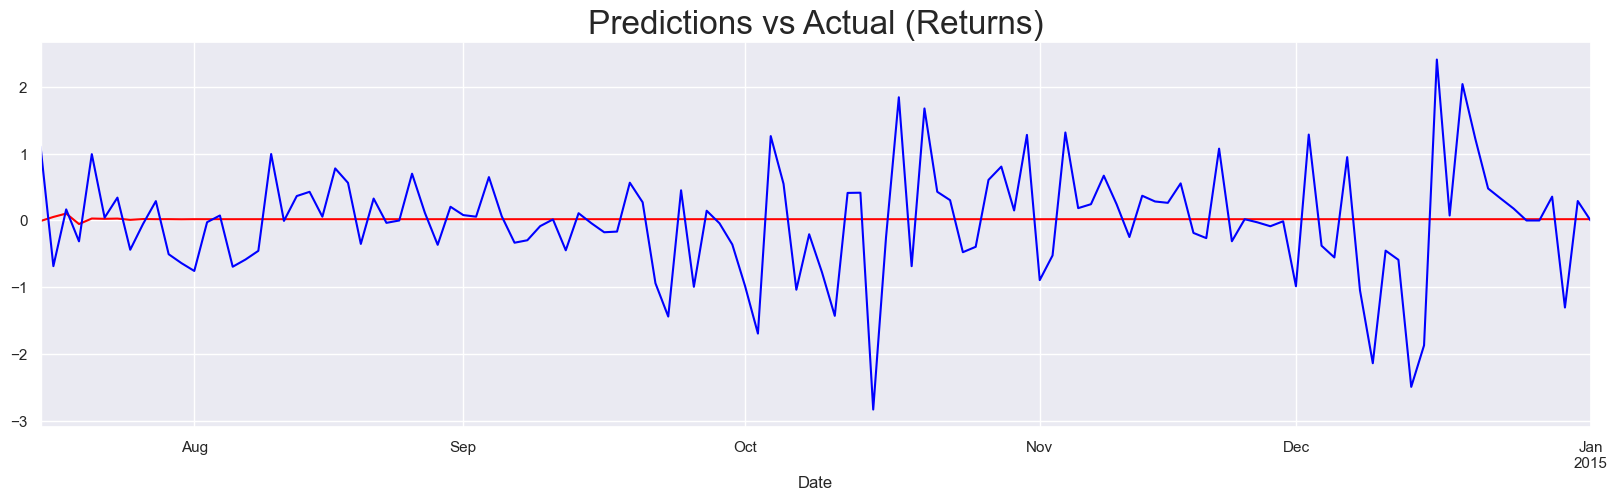

In [26]:
model_ret_arma = ARIMA(df.ret_ftse[1:], order=(5,0,1))
results_ret_arma = model_ret_arma.fit()

df_pred_arma = results_ret_arma.predict(start = start_date, end = end_date)

df_pred_arma[start_date:end_date].plot(figsize = (20,5), color = "red")   
df_test.ret_ftse[start_date:end_date].plot(color = "blue")
plt.title("Predictions vs Actual (Returns)", size = 24)
plt.show()

In [27]:
df_pred_arma.head()

2014-07-16   -0.007708
2014-07-17    0.053165
2014-07-18    0.104015
2014-07-21   -0.053230
2014-07-22    0.029506
Freq: B, Name: predicted_mean, dtype: float64

In [28]:
df_pred_arma.tail()

2014-12-26    0.019165
2014-12-29    0.019165
2014-12-30    0.019165
2014-12-31    0.019165
2015-01-01    0.019165
Freq: B, Name: predicted_mean, dtype: float64

The ARMA provides more reasonable predictions as they don't just die off immediately.  
The shifts are always in the same direction.  
We will still be having constantly decreasing returns, which isn't very realistic

### ARMAX

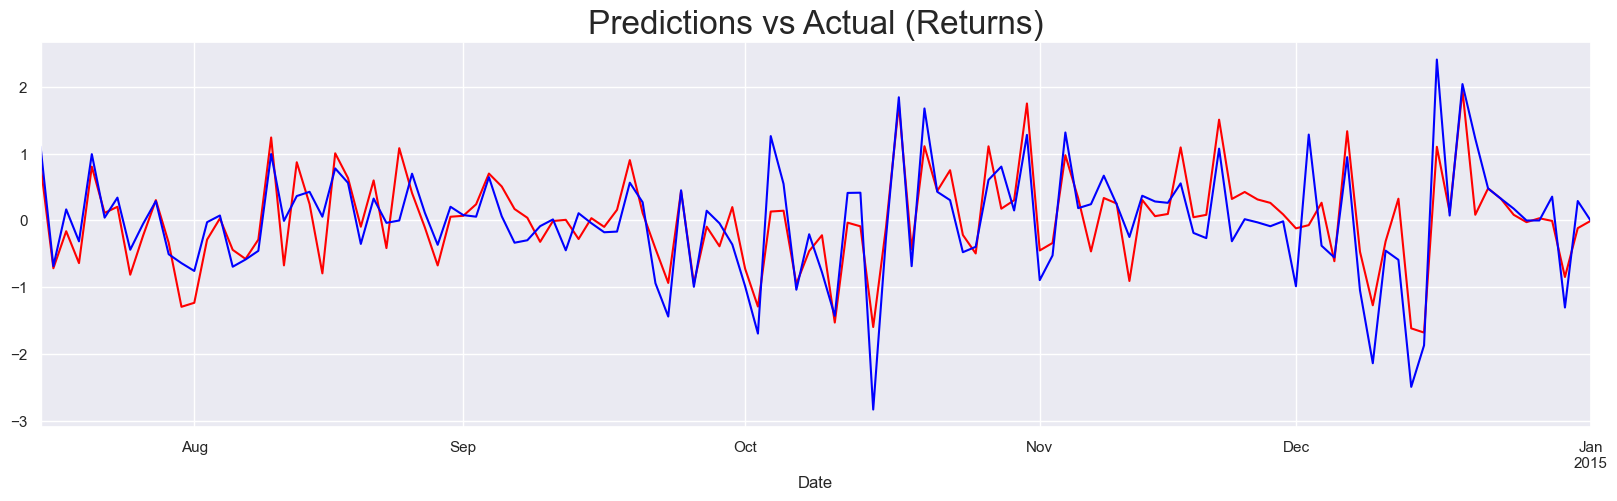

In [29]:
model_ret_armax = ARIMA(df.ret_ftse[1:], exog = df[["ret_spx","ret_dax","ret_nikkei"]][1:], order = (1,0,1))
results_ret_armax = model_ret_armax.fit()

df_pred_armax = results_ret_armax.predict(start = start_date, end = end_date, 
                                          exog = df_test[["ret_spx","ret_dax","ret_nikkei"]][start_date:end_date]) 

df_pred_armax[start_date:end_date].plot(figsize = (20,5), color = "red")
df_test.ret_ftse[start_date:end_date].plot(color = "blue")
plt.title("Predictions vs Actual (Returns)", size = 24)
plt.show()

This is extremley usefull because it makes estimations a lot more precise as we can clearly see.  
Although they can greatly improve the accuracy of our predictions, they can make forecasting impossible.  
We use predictions when we're discussing in-sample estimations and forecast when we're talking about out-of-sample estimations.  
Now you see why MAX models can be great when we're analyzing data, but poor when we're trying to forecast

### SARMA

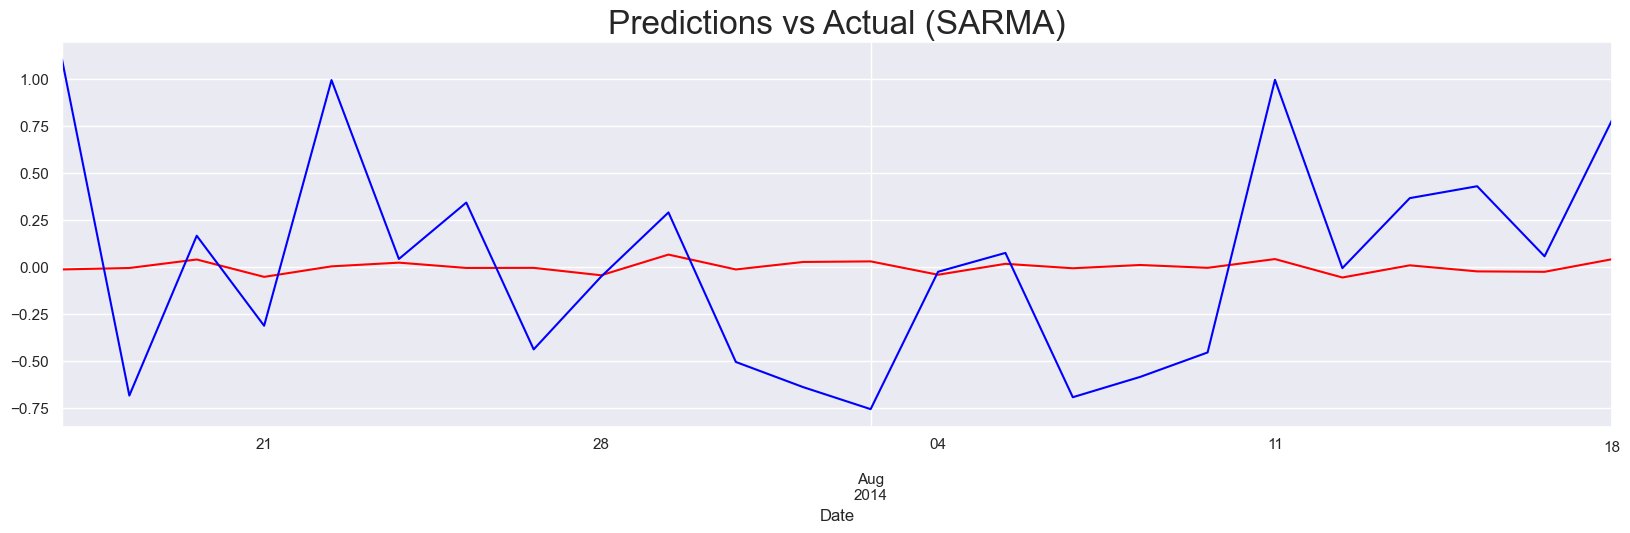

In [30]:
end_date = "2014-08-18"
model_ret_sarma = SARIMAX(df.ret_ftse[1:], order = (3,0,4), seasonal_order = (3,0,2,5))
results_ret_sarma = model_ret_sarma.fit()

df_pred_sarma = results_ret_sarma.predict(start = start_date, end = end_date)

df_pred_sarma[start_date:end_date].plot(figsize = (20,5), color = "red")
df_test.ret_ftse[start_date:end_date].plot(color = "blue")
plt.title("Predictions vs Actual (SARMA)", size = 24)
plt.show()

SARMA models anticipate greater stability than the MAX model we examined earlier.  
Ther accuracy is lacking.

### SARIMAX

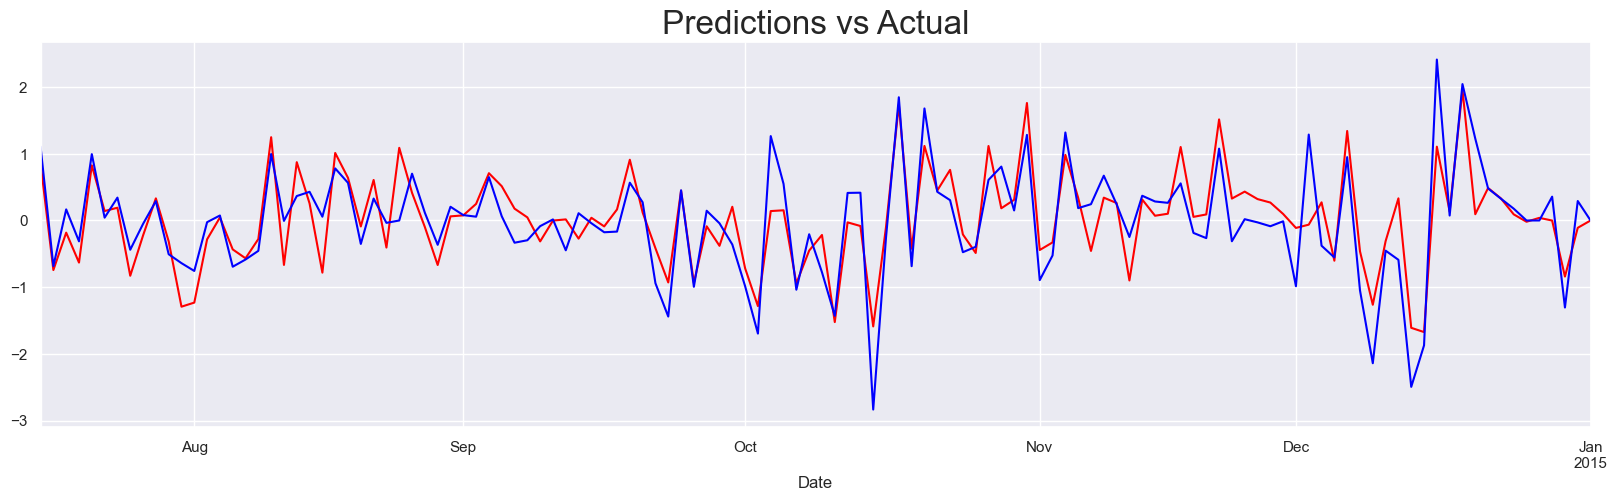

In [31]:
end_date = "2015-01-01"
model_ret_sarimax = SARIMAX(df.ret_ftse[1:], exog = df[["ret_spx","ret_dax","ret_nikkei"]][1:], 
                            order = (3,0,4), seasonal_order = (3,0,2,5))
results_ret_sarimax = model_ret_sarimax.fit()

df_pred_sarimax = results_ret_sarimax.predict(start = start_date, end = end_date, 
                                              exog = df_test[["ret_spx","ret_dax","ret_nikkei"]][start_date:end_date]) 

df_pred_sarimax[start_date:end_date].plot(figsize = (20,5), color = "red")
df_test.ret_ftse[start_date:end_date].plot(color = "blue")
plt.title("Predictions vs Actual", size = 24)
plt.show()

Adding exogenous variables drastically changes our predictions, but poor in forecasting

### Auto ARIMA

In [32]:
model_auto = auto_arima(df.ret_ftse[1:], exogenous = df[['ret_spx', 'ret_dax', 'ret_nikkei']][1:],
                       m = 5, max_p = 5, max_q = 5, max_P = 5, max_Q = 5)

In [33]:
df_auto_pred = pd.DataFrame(model_auto.predict(n_periods = len(df_test[start_date:end_date]),
                            exogenous = df_test[['ret_spx', 'ret_dax', 'ret_nikkei']][start_date:end_date]),
                            index = df_test[start_date:end_date].index)

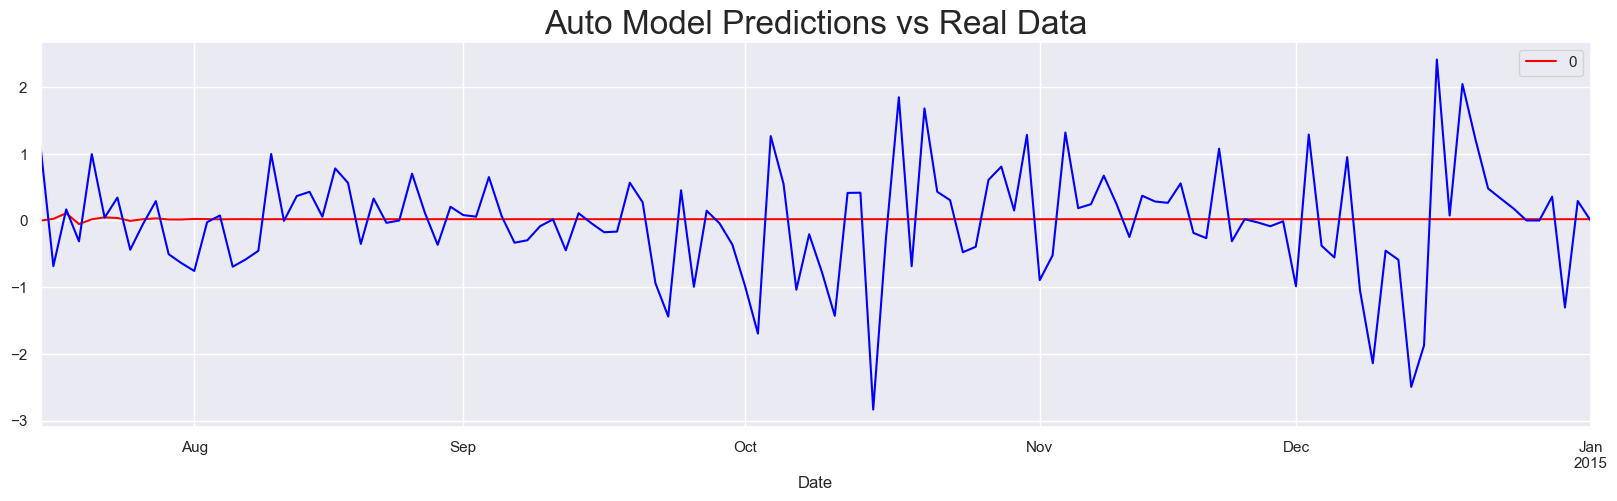

In [34]:
df_auto_pred.plot(figsize = (20,5), color = "red")
df_test.ret_ftse[start_date:end_date].plot(color = "blue")
plt.title("Auto Model Predictions vs Real Data", size = 24)
plt.show()

We see that the predictions don't really match the curve as closely as the SARIMAX model did.  
There are two obvious steps that are bound to result in a better fitting model.  
The first one is including exogenous variables once again if you decide to do so, be careful because you need to pass the values to the exogenous argument rather then the exog we've been using so far. What we get is a curve that matches the testing set far better.  
As long as we provide the auto_arima method enough information, it's bound to give us a reasonable solution
We notice how all the models that perform well, rely on exogenous variables. However, those are hardly ever available when we want to make long term predictions.  
We're reiterating this because our MAX models rely on outside data much more than the do on past values or past errors 

### Comparing All the Models (Returns)

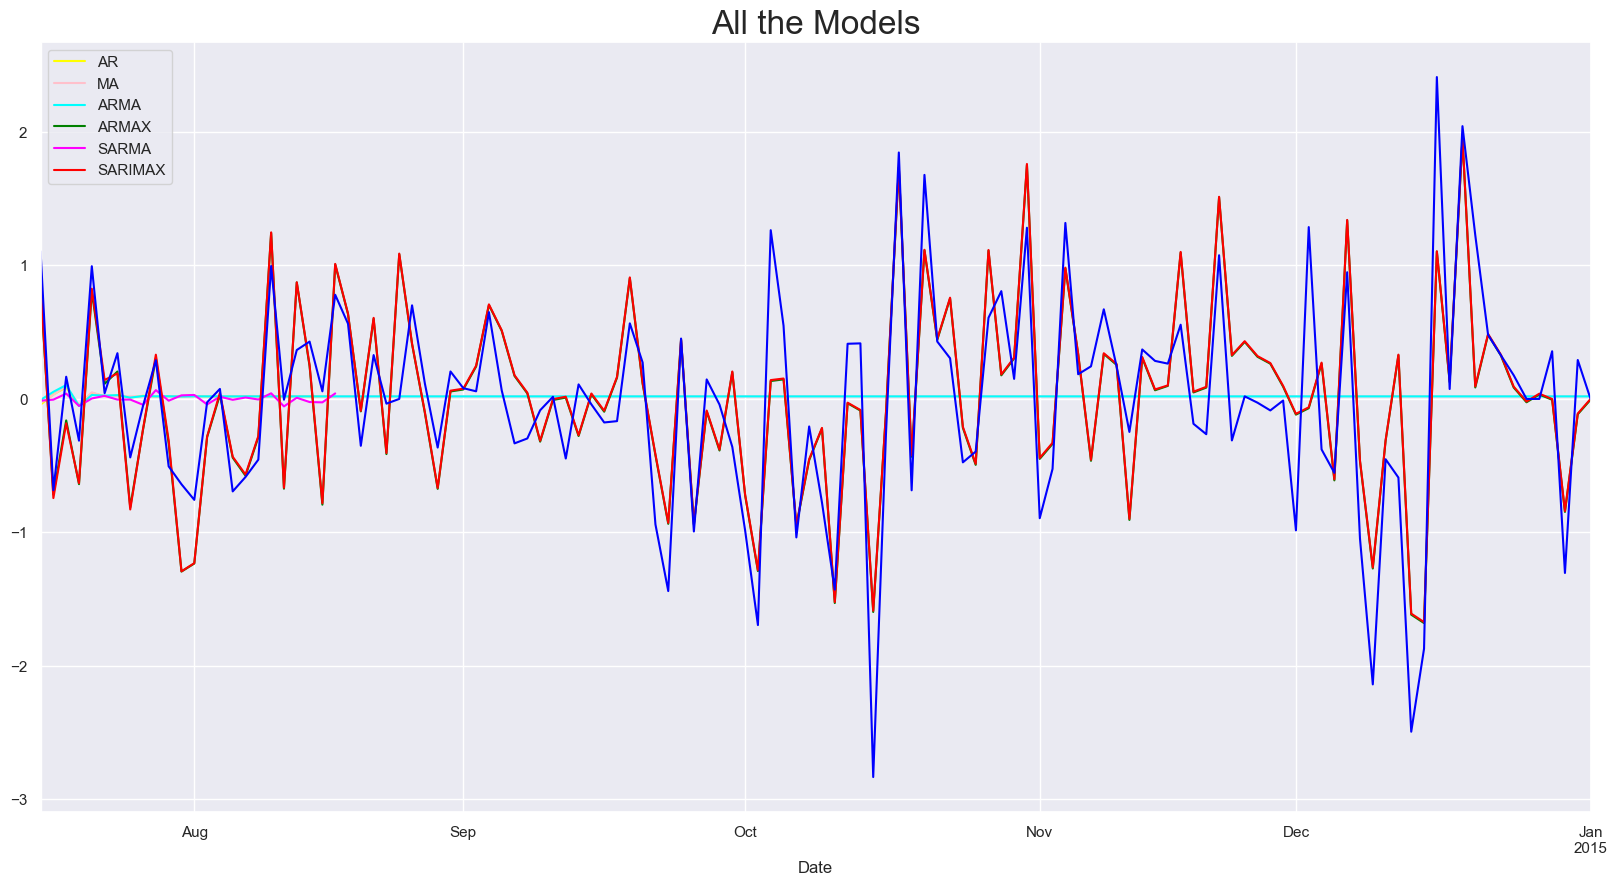

In [35]:
end_date = "2015-01-01"
df_pred_ar[start_date:end_date].plot(figsize = (20,10), color = "yellow")
df_pred_ma[start_date:end_date].plot(color = "pink")
df_pred_arma[start_date:end_date].plot(color = "cyan")
df_pred_armax[start_date:end_date].plot(color = "green")
df_pred_sarma[start_date:end_date].plot(color = "magenta")
df_pred_sarimax[start_date:end_date].plot(color = "red")
df_test.ret_ftse[start_date:end_date].plot(color = "blue")
plt.legend(['AR','MA','ARMA','ARMAX','SARMA','SARIMAX'])
plt.title("All the Models", size = 24)
plt.show()

The AR model:  
 It only depends on the past values and the constant coefficient.
 The more past legs we include, the more time it takes to flatten out
 However, the monotonous nature of the predictions makes it unreasonable, since we don't really expect prices or returns to constantly be going down

The MA model:  
 We can't make long run predictions if we're relying on error terms.  
 We can't autogenerate future residuals since we don't have actual values anymore.  

Note: If the exogenous variables are other time series as well, we'll run into some trouble

Most of the models we looked at experienced some issues.  
Making accurate forecast with the ARMA family of models isn't that easy.  
However, what if we didn't forecast the values themselves?
Instead, we can focus on their volatility to determine the stability of certain markets.

### Forecasting Volatility

In [36]:
mod_garch = arch_model(df_comp.ret_ftse[1:], vol = "GARCH", p = 1, q = 1, mean = "constant", dist = "Normal")
res_garch = mod_garch.fit(last_obs = start_date, update_freq = 10)

Iteration:     10,   Func. Count:     65,   Neg. LLF: 7310.6160151020895
Optimization terminated successfully    (Exit mode 0)
            Current function value: 7310.616005371661
            Iterations: 12
            Function evaluations: 74
            Gradient evaluations: 12


In [37]:
pred_garch = res_garch.forecast(horizon = 1, align = 'target')
# horizon = how many observations we want our model predict for each date. That way, for each date, we'll get the predicted value, for the next date.
# align = determines wheter we match the value with the date the prediction is made on, or the one it's supposed to represent.
# align = 'target' means we match the value with the date it's supposed to represent. For example, if we predict the volatility for Jan 2nd on Jan 1st, with align = 'target', the predicted volatility will be matched to Jan 2nd.

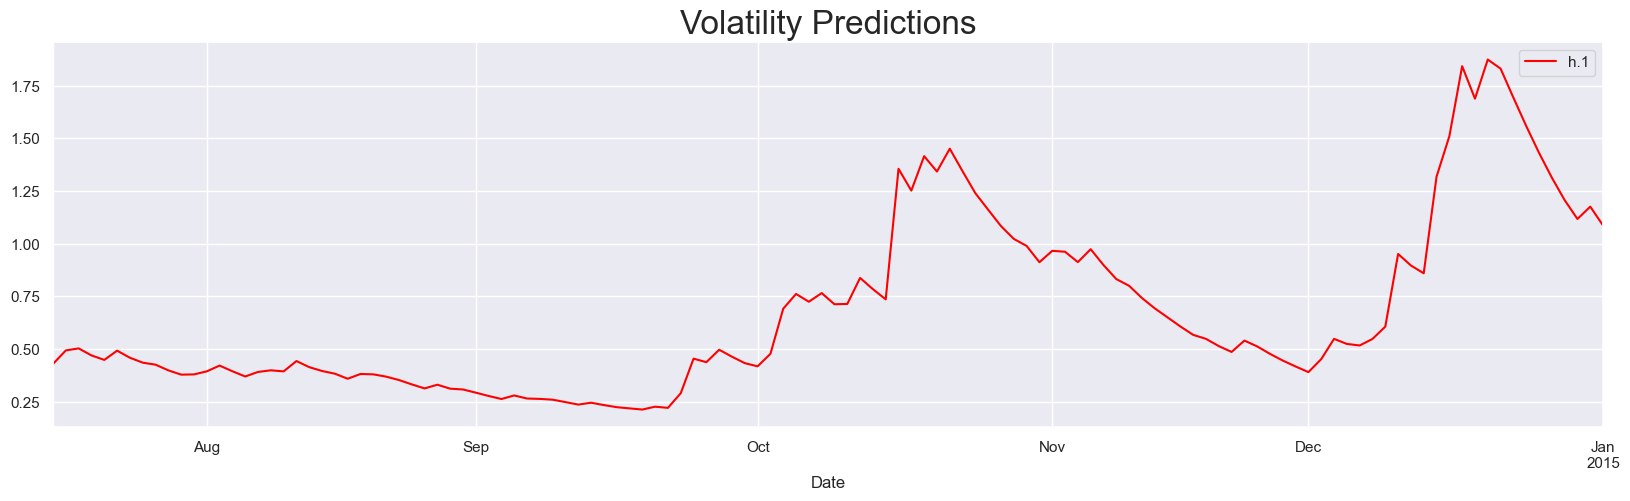

In [38]:
pred_garch.residual_variance[start_date:end_date].plot(figsize = (20,5), color = "red")
plt.title("Volatility Predictions", size = 24)
plt.show()

In [39]:
# Our volatility predictions aren't linear like the ARMA models, but fluctuate based on the past conditional variance. It captures the changing nature of volatility over time.

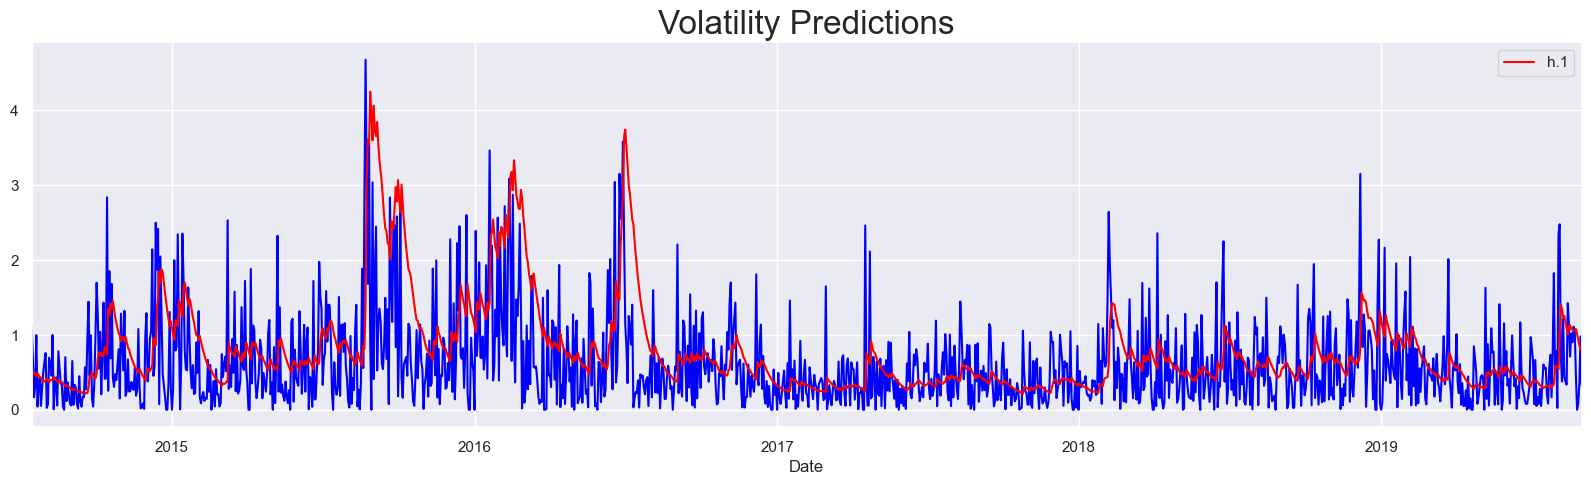

In [40]:
pred_garch.residual_variance[start_date:].plot(figsize = (20,5), color = "red", zorder = 2)
df_test.ret_ftse.abs().plot(color = "blue", zorder = 1)
plt.title("Volatility Predictions", size = 24)
plt.show()
# The zorder parameter controls the layering of plot elements. Higher zorder values are drawn on top of lower ones. 
# This ensures that the predicted volatility is plotted on top of the actual volatility.

In [41]:
# Our model does a decent job at capturing the volatility spikes, although it sometimes underestimates or overestimates the actual volatility. 
# Also, during low volatility periods, the predictions are quite close to the actual values.

Our model does a decent job predicting when shocks will happen and does very well at determinig periods of consecutive high and low volatility. It is usually a bit conservative duriing some transitional periods, but provides some good estimations.  
How is it different from the models we've observed so far? We're still only predicting values within the testing set rather than forecasting the future.  
Well, we can do that too as we explained earlier, the horizon argument determines how many arguments we want to predict forward for each date.  
Currently we have it set equal to one because we're only forecasting the value for tomorrow for each date passing date.
However, if we're forecasting, we don't need the one step ahead prediction for many days, but the exact opposite the many-step ahead prediction for a single day

In [42]:
pred_garch = res_garch.forecast(horizon = 100, align = 'target')
pred_garch.residual_variance[-1:]
# horizon = 100 means we want to predict volatility for the next 100 business days.

,h.001,h.002,h.003,h.004,h.005,h.006,h.007,h.008,h.009,h.010,...,h.091,h.092,h.093,h.094,h.095,h.096,h.097,h.098,h.099,h.100
Date,,,,,,,,,,,,,,,,,,,,,
2019-08-30,0.810953,0.805082,0.866929,0.940634,1.021137,1.085725,1.074809,1.06858,1.082128,1.091659,...,0.841664,0.843269,0.834763,0.820076,0.831594,0.8437,0.854891,0.868261,0.875738,0.890048


Finally we able to forecast a model into the future!  
However, it's one that measures volatility rather than returns, and we can't transform those to get some price estimates.
Before we started exploring volatility models, we mentionated that this is one of the ways we can go around this issue of missing exogenous variables.  
The other solution involves forecasting the values of each of these exogenous variables as well.

### Forecasting the volatility 2

In [43]:
start_date2 = '2014-06-18'

In [44]:
mod_garch2 = arch_model(df.ret_ftse[1:], vol = "GARCH", p = 1, q = 1, mean = "constant", dist = "Normal")
res_garch2 = mod_garch2.fit(last_obs = start_date2, update_freq = 10)

Iteration:     10,   Func. Count:     65,   Neg. LLF: 7293.953038697632
Optimization terminated successfully    (Exit mode 0)
            Current function value: 7293.953030991765
            Iterations: 12
            Function evaluations: 74
            Gradient evaluations: 12


In [45]:
pred_garch2 = res_garch2.forecast(horizon = 20, align = 'target')
res_var_mod2 = pred_garch2.residual_variance[-1:]
res_var_mod2

,h.01,h.02,h.03,h.04,h.05,h.06,h.07,h.08,h.09,h.10,h.11,h.12,h.13,h.14,h.15,h.16,h.17,h.18,h.19,h.20
Date,,,,,,,,,,,,,,,,,,,,
2014-07-15,0.431128,0.413184,0.444077,0.435278,0.460101,0.353039,0.341369,0.365595,0.353183,0.374824,0.342266,0.358017,0.372506,0.394403,0.361596,0.376158,0.382915,0.399118,0.407413,0.426248


In [46]:
df_res_var_mod2 = pd.DataFrame(data = res_var_mod2.values.T, index = df_test[:20].index,
                                columns = ['ret_ftse_pred'])
df_res_var_mod2

,ret_ftse_pred
Date,
2014-07-16,0.431128
2014-07-17,0.413184
2014-07-18,0.444077
2014-07-21,0.435278
2014-07-22,0.460101
2014-07-23,0.353039
2014-07-24,0.341369
2014-07-25,0.365595
2014-07-28,0.353183


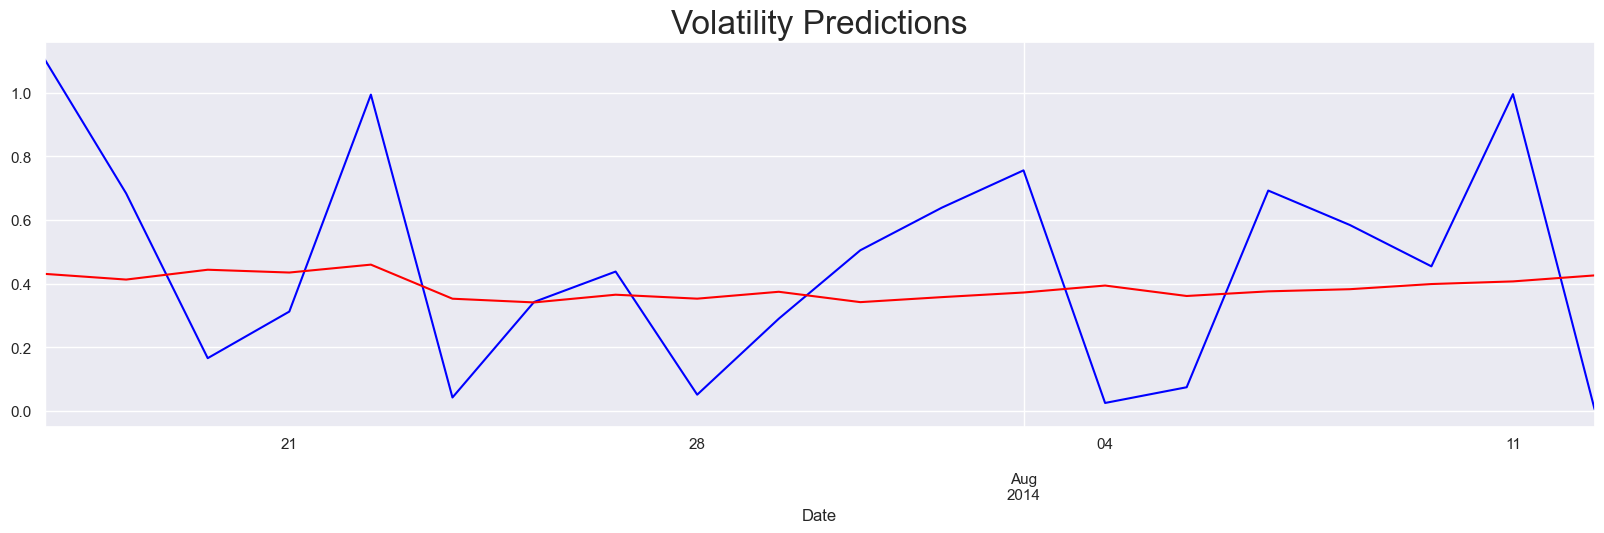

In [47]:
df_res_var_mod2.ret_ftse_pred.plot(figsize = (20,5), color = "red", zorder = 2)
df_test[:20].ret_ftse.abs().plot(color = "blue", zorder = 1)
plt.title("Volatility Predictions", size = 24)
plt.show()

### Multvariate Regression Model

A multivariate regression is just several regressions in a trench coat, In other words, we have regressions stacked on top of one anothe, one for each time series we're including

In [48]:
from statsmodels.tsa.api import VAR

In [49]:
df_ret = df[['ret_spx', 'ret_dax', 'ret_ftse', 'ret_nikkei']][1:]

In [50]:
model_var_ret = VAR(df_ret)
model_var_ret.select_order(20)
results_var_ret = model_var_ret.fit(ic = 'aic')
# selec_order(n) : Whatever numeric we pass will serve as the maximum order of the model. The more time series we are using, the higher this number should be.
# ic = 'aic' means we want to use the Akaike Information Criterion to select the best lag order.

In [51]:
results_var_ret.summary()
# This summary provides an overview of the fitted VAR model, including coefficients, standard errors, t-statistics, p-values, and information criteria for model selection. 
# Yo can read this summary to understand the relationships between the different time series in the VAR model.

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 01, Feb, 2026
Time:                     21:49:44
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   0.328077
Nobs:                     5346.00    HQIC:                  0.260760
Log likelihood:          -30859.0    FPE:                    1.25185
AIC:                     0.224624    Det(Omega_mle):         1.23237
--------------------------------------------------------------------
Results for equation ret_spx
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                 0.039221         0.016160            2.427           0.015
L1.ret_spx           -0.110815         0.017560           -6.310           0.000
L1.ret_dax            0.064819         0.019027           

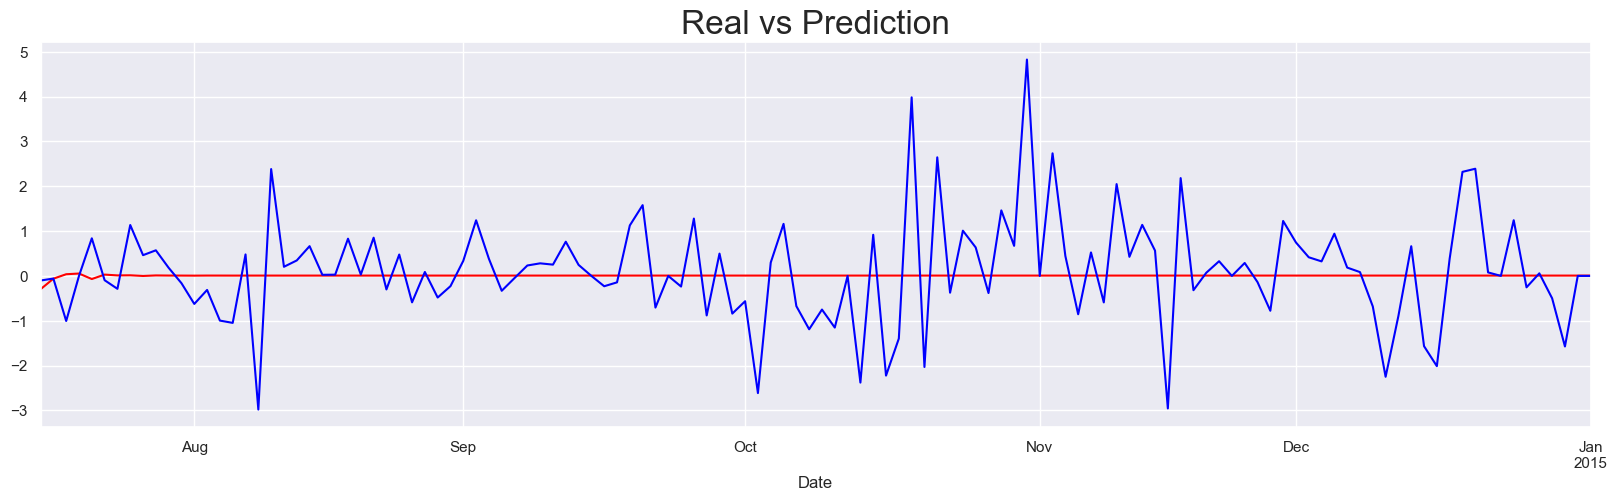

In [52]:
lag_order_ret = results_var_ret.k_ar
var_pred_ret = results_var_ret.forecast(df_ret.values[-lag_order_ret:], len(df_test[start_date:end_date]))

df_ret_pred = pd.DataFrame(data = var_pred_ret, index = df_test[start_date:end_date].index,
                                columns = df_test[start_date:end_date].columns[4:8])

df_ret_pred.ret_nikkei[start_date:end_date].plot(figsize = (20,5), color = "red")

df_test.ret_nikkei[start_date:end_date].plot(color = "blue")
plt.title("Real vs Prediction", size = 24)
plt.show()

We're only including past values for these additional time series. Therefore, we're not including the extremely valuable input of today's values into the mix.  
This is why the model performs just like an expanded AR model.

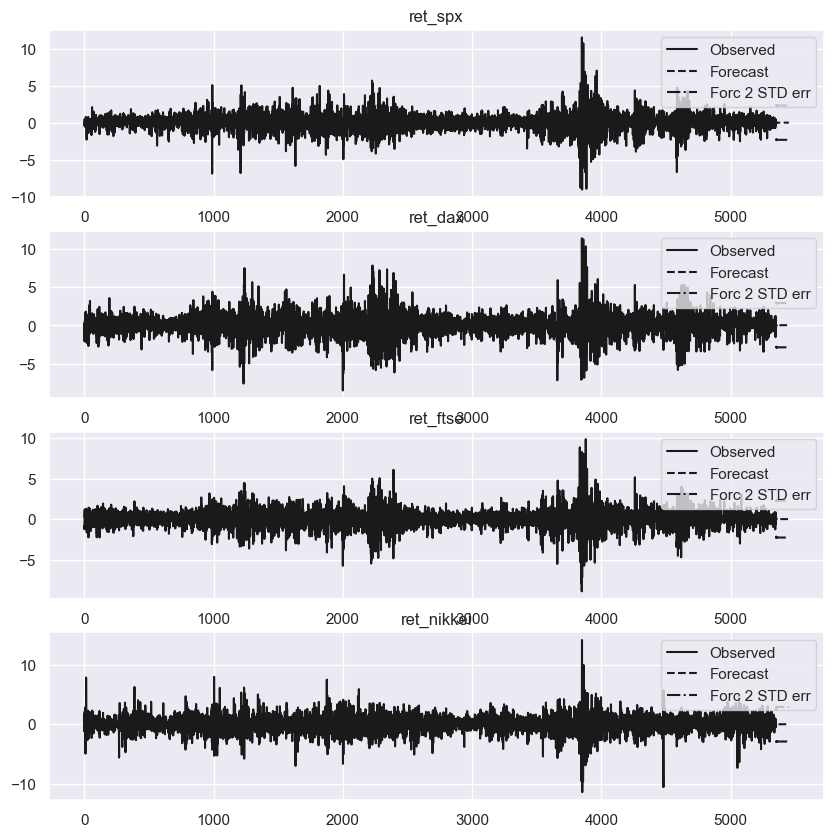

In [53]:
results_var_ret.plot_forecast(100)
plt.show()
# This plot shows the forecasted values for each time series in the VAR model over the next 100 periods, along with confidence intervals.
# the plots help visualize the expected future values and the uncertainty associated with those forecasts.

That way we get a 95% range for the returns of every market index moving forward. This will give us a great idea of wheter we see long term stability in the market.
Assuming no unpredictable event occurs.